R square 0.7695843778979886  
MSE 154.77282109556333
Median absolute error 6.688182830810547
Explained varience 0.7772774130778318
Pearson correlation 0.8818996283488887
Spearman correlation 0.8686830038193181


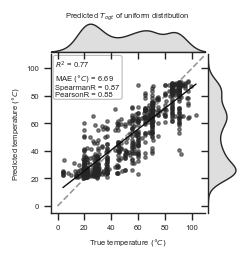

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="ticks", context="paper")

#Load regression prediction data 


#x, y = arr[:,1], arr[:,0]

#df = pd.DataFrame({"Predicted OGT": x, "True OGT": y})

df = pd.read_csv("../Data/Figure1/Evaluation_regression_downsampled_test_set.csv")

# Statistics

r = sklearn.metrics.r2_score(df["True OGT"], df["Predicted OGT"])
e = sklearn.metrics.explained_variance_score(df["True OGT"], df["Predicted OGT"])
mse = sklearn.metrics.mean_squared_error(df["True OGT"], df["Predicted OGT"])
mdi = sklearn.metrics.median_absolute_error(df["True OGT"], df["Predicted OGT"])

corr_p, _ = pearsonr(df["True OGT"], df["Predicted OGT"])
corr_s, _ = spearmanr(df["True OGT"], df["Predicted OGT"])
print("R square {}  ".format(r))
print("MSE {}".format(mse))
print("Median absolute error {}".format(mdi))
print("Explained varience {}".format(e))
print("Pearson correlation {}".format(corr_p))
print("Spearman correlation {}".format(corr_s))


SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# --- style ---
plt.rcParams.update({
    "font.size": 5.5,
    "axes.labelsize": 5.5,
    "axes.titlesize": 5.5,
    "figure.titlesize": 5.5,
    "axes.linewidth": 1,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 5.5,
    "legend.fontsize": 5.5,
})
mm = 1 / 25.4
fig_w = 60 * mm
fig_h = 60 * mm


#fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# JointGrid with marginal KDEs
g = sns.JointGrid(
    data=df, x="True OGT", y="Predicted OGT",
    height=fig_h, ratio=5, space=0.08, marginal_ticks=False
)

# --- Main panel: scatter + regression line (or omit regression if you prefer) ---
sns.regplot(
    data=df, x="True OGT", y="Predicted OGT",
    ci=None,
    scatter_kws={"s": 6, "alpha": 0.55, "color": "0.15"},
    line_kws={"color": "0.05", "lw": 1},
    ax=g.ax_joint
)

# Identity line y=x
g.ax_joint.plot([0, 110], [0, 110], ls="--", lw=1.2, color="0.6", zorder=0)

# --- Marginals: KDEs on axes ---
sns.kdeplot(
    data=df, x="True OGT",
    ax=g.ax_marg_x, color="0.15", lw=1, fill=True, alpha=0.15, clip=(-5, 110)
)
sns.kdeplot(
    data=df, y="Predicted OGT",
    ax=g.ax_marg_y, color="0.15", lw=1, fill=True, alpha=0.15, clip=(-5, 110)
)

# Limits + labels + title
g.ax_joint.set_xlim(-5, 110)
g.ax_joint.set_ylim(-5, 110)

g.ax_joint.set_xlabel(r"True temperature $(\degree C)$")
g.ax_joint.set_ylabel(r"Predicted temperature $(\degree C)$")
#g.ax_joint.set_title(r"Predicted $T_{ogt}$ of uniform distribution", pad=12)
g.fig.suptitle(r"Predicted $T_{ogt}$ of uniform distribution", y=1.02)
# Optional: statistics text box in joint axis
textstr = "\n".join([
    fr"$R^2$ = {r:.2f}",
    fr"MAE $(\degree C)$ = {mdi:.2f}",
    fr"SpearmanR = {corr_s:.2f}",
    fr"PearsonR = {corr_p:.2f}",
])
g.ax_joint.text(
    0.03, 0.97, textstr, transform=g.ax_joint.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

sns.despine(ax=g.ax_joint)
sns.despine(ax=g.ax_marg_x, left=True)
sns.despine(ax=g.ax_marg_y, bottom=True)

plt.savefig("img_reg_marginal_kde.pdf", bbox_inches="tight")
plt.show()